In [1]:
###testing R in jyupter 

In [2]:
library(purrr)
library(tidyverse)
library(edgeR)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ dplyr   1.0.9
✔ tibble  3.1.7     ✔ stringr 1.4.0
✔ tidyr   1.2.0     ✔ forcats 0.5.1
✔ readr   2.1.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: limma



In [3]:
lfbl=function(pattern,level=1){
    if(!exists("lof")) lof=vector("character",0)
    temp=list.files(pattern=pattern,no..=T)
    if(!is.na(temp[1])) lof=c(lof,paste0(getwd(),"/",temp))
    if(level>0){
        dirf=list.dirs(full.names=F,recursive=F)
        for(i in dirf){
            setwd(i)
            lof=c(lof,lfbl(pattern,level-1))
            setwd("..")
        }
    }
    return(lof)
}




In [4]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106")
getwd()

[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106"

In [5]:
f_files = lfbl(pattern = 'featureCounts$',level=1)
f_files


[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts"
  [7] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts"
  [8] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts"
  [9] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts"
 [10] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-12.5dpp.1.featureCounts"                
 [11] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-12.5dpp.2.featureCounts"                
 [12] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-12.5dpp.3.featureCounts"                
 [13] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-16.5dpc.1.featureCounts"                
 [14] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-16.5dpc.2.featureCounts"                
 [15] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-16.5dpc.3.featureCounts"                
 [16] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-20.5dpp.1.featureCounts"                
 [17] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-20.5dpp.2.featureCounts"                
 [18] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/A_J/A_J-20.5dpp.3.featureCounts"                
 [19] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/AKR_J/AKR_J-12.5dpp.1.featureCounts"            
 [20] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/AKR_J/AKR_J-12.5dpp.2.featureCounts"            
 [21] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/AKR_J/AKR_J-12.5dpp.3.featureCounts"            
 [22] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/AKR_J/AKR_J-16.5dpc.1.featureCounts"            
 [23] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/AKR_J/AKR_J-16.5dpc.2.featureCounts"            
 [24] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/result

In [6]:

groups = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
groups

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [16] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [19] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [22] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
 [25] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
 [28] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [31] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [34] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [37] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
 [40] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
 [43] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
 [46] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [49] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [52] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [55] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [58] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [61] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [64] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
 [67] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
 [70] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [73] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
 [76] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
 [79] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
 [82] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
 [85] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [88] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [91] "LP_J-12.5dpp"        "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [94] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [97] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[100] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[103] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[106] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[109] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"  
[112] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"  
[115] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[118] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[121] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[124] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[127] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[130] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[133] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[136] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[139] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[142] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [7]:

#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [8]:
	
df = readDGE(f_files, path=NULL, columns=c(1,7), group= groups, labels = lables,sep="\t" ,skip = 1)

In [9]:
head(df)

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,14483798,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,22094102,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,13978214,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,5977982,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,5943594,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,6694684,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,5530727,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,5428720,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,5327041,1


In [10]:
mircounts <- df$counts

In [11]:
df$samples

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,14483798,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,22094102,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,13978214,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,5977982,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,5943594,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,6694684,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,5530727,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,5428720,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/GRCm39_106/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,5327041,1


In [12]:
#DESeq and PCA and Dandogram 


library("DESeq2")
library("gplots")
library("RColorBrewer")
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

#save results in this folder 
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/transcriptCount/GRcm39.106")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘packa

In [13]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)

In [14]:
# First we tell DESeq which samples correspond to which tissues.
samplenames <- tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"


In [15]:
# Now we build a DESeq2 Count dataset and normalize it.
cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
cds <- estimateSizeFactors(cds)
cds <- estimateDispersions(cds)
cds <- nbinomWaldTest(cds)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substi

In [ ]:
 R.home()

[1] "/nfs/users/nfs_n/nm17/miniconda3/envs/snakemake/lib/R"

In [17]:
#rlog normalisations
rl=vst(cds)


In [18]:

pdf("BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")

postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")
dev.off()



png 
  2

In [19]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(timePoint) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("12.5","16.5","20.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",timePoint,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "12.5"
[1] "16.5"
[1] "20.5"


In [20]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+
    theme_bw() + theme(legend.text=element_text(size=5))

  
}

pdf("PCA_After_1vs2_Beginning.pdf",paper="a4")
plotPCA.san(rl, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [21]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(strain) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (strain in strains) {
print(strain)
rl.sub <- rl[ , rl$sample %in%  grep(paste0("^",strain), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",strain,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "129S1_SvImJ"
[1] "A_J"
[1] "AKR_J"
[1] "BALB_cJ"
[1] "C3H_HeJ"
[1] "C57BL_6NJ"
[1] "CAST_EiJ"
[1] "CBA_J"
[1] "DBA_2J"
[1] "FVB_NJ"
[1] "LP_J"
[1] "NOD_ShiLtJ"
[1] "NZO_HlLtJ"
[1] "PWK_PhJ"
[1] "SPRET_EiJ"
[1] "WSB_EiJ"


In [22]:

##To plot PC2 versus 3
library(genefilter)
library(ggplot2)
library(ggrepel)

plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[2:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_3.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


The following object is masked from ‘package:readr’:

    spec




png 
  2

In [23]:
##To plot PC1 versus 3
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_4.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [24]:
####

pdf("InitialHeatMap.pdf",paper="special",width=25000, height=25000,title="Trinity Assemblies",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()


png 
  2

In [28]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="dendrogram.pdf", height=100, width=30)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3
,<dbl>,<dbl>,<dbl>
ENSMUST00000193198,0.000000,0.0000000,0.0000000
ENSMUST00000191430,0.000000,0.0000000,0.0000000
ENSMUST00000181451,1.313903,0.7856769,0.6124356
ENSMUST00000194081,0.000000,0.0000000,0.0000000
ENSMUST00000194393,0.000000,0.0000000,0.0000000
ENSMUST00000132100,0.000000,0.3928385,0.0000000


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000193198,0.0000000,0.8089479,0.000000,1.315671,0.0000000,0.000000,0.1333173,0.000000,0.000000,0.57855757,⋯,1.0787299,0.5096083,1.2773270,0.0000000,3.7807775,6.3320809,3.3355238,0.4883954,0.3400586,0.3511009
ENSMUST00000191430,0.0000000,0.0000000,2.009479,0.000000,0.0000000,1.553874,0.0000000,0.000000,0.000000,0.00000000,⋯,0.0000000,0.0000000,0.0000000,0.2735099,0.0000000,0.0000000,0.0000000,0.0000000,0.3767154,0.3060236
ENSMUST00000181451,0.9040051,160.3433277,6.215143,6.077940,34.9369127,1.553874,10.3965698,95.974106,5.857864,1.14094815,⋯,5.2029190,0.7659359,3.4485827,0.0000000,1.4193837,10.1951596,0.2665678,0.6707268,72.7027156,0.0000000
ENSMUST00000194081,0.0000000,0.4649563,0.000000,0.000000,0.3138979,0.000000,0.0000000,37.410924,0.000000,0.00000000,⋯,0.5393649,0.0000000,0.8310909,0.0000000,1.5899510,0.6326558,0.4883448,0.2126698,0.7192359,0.0000000
ENSMUST00000194393,0.0000000,2.2253822,0.000000,0.000000,0.0000000,0.000000,0.0000000,3.660927,0.000000,0.08745785,⋯,0.0000000,0.0000000,2.6167636,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000
ENSMUST00000132100,0.1309462,0.0000000,0.000000,0.000000,1.0385055,0.000000,0.1237693,1.749688,0.000000,0.05974073,⋯,0.0000000,0.3113246,0.0000000,0.0000000,0.3571057,0.3049118,0.0000000,0.2954162,1.8469203,0.0000000


[1] 142438

[1] 3959

,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000027629,24108.3980,27086.671,7464.87504,24941.4583,23051.690,9298.65061,26341.0945,33232.800,8695.41541,24883.4762,⋯,13644.75850,15735.7229,16720.833,5495.00346,1.494874e+04,21490.50674,8481.657465,32550.5023,20179.72,10938.34108
ENSMUST00000015628,117.0387,12515.046,26.10216,267.5337,13271.215,86.41633,371.0411,15332.734,87.39712,401.6245,⋯,186.45107,176.2999,4174.973,35.71306,6.098520e+02,8610.95656,161.171664,132.5215,12454.33,60.45569
ENSMUST00000166172,121887.4665,41793.048,30186.73289,126782.6433,71451.869,55399.47714,142890.9592,114467.071,52721.36275,156388.0530,⋯,62622.20371,175349.9475,45473.197,58542.59322,1.954043e+05,115639.10311,89079.367824,114636.6953,25880.57,46597.15808
ENSMUST00000188299,909.9906,4983.224,432.46482,533.8690,19186.045,178.25824,754.9312,37262.251,233.58416,187.2957,⋯,859.53469,960.6037,2816.517,168.24018,2.048504e+00,40.04392,1.910846,234.9303,13776.21,58.77177
ENSMUST00000162226,24865.1222,29958.370,15691.11986,21951.9847,35569.434,13274.07075,27770.5330,45737.110,31452.09587,17291.8634,⋯,27563.69946,27324.7727,38146.206,12731.69316,1.013127e+04,16959.72952,11675.388356,23749.7820,30459.96,15090.37511
ENSMUST00000161229,131.0513,2158.677,60.83466,239.4872,3406.888,96.62889,180.7926,3959.294,62.07185,188.2905,⋯,65.55837,214.4694,2448.935,72.17125,3.302000e+02,21587.58333,120.152802,837.5022,28856.84,163.45294


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUST00000027629,24108.3980,27086.671,7464.87504,24941.4583,23051.690,9298.65061,26341.0945,33232.800,8695.41541,24883.4762,⋯,15735.7229,16720.833,5495.00346,1.494874e+04,21490.50674,8481.657465,32550.5023,20179.72,10938.34108,ENSMUST00000027629
ENSMUST00000015628,117.0387,12515.046,26.10216,267.5337,13271.215,86.41633,371.0411,15332.734,87.39712,401.6245,⋯,176.2999,4174.973,35.71306,6.098520e+02,8610.95656,161.171664,132.5215,12454.33,60.45569,ENSMUST00000015628
ENSMUST00000166172,121887.4665,41793.048,30186.73289,126782.6433,71451.869,55399.47714,142890.9592,114467.071,52721.36275,156388.0530,⋯,175349.9475,45473.197,58542.59322,1.954043e+05,115639.10311,89079.367824,114636.6953,25880.57,46597.15808,ENSMUST00000166172
ENSMUST00000188299,909.9906,4983.224,432.46482,533.8690,19186.045,178.25824,754.9312,37262.251,233.58416,187.2957,⋯,960.6037,2816.517,168.24018,2.048504e+00,40.04392,1.910846,234.9303,13776.21,58.77177,ENSMUST00000188299
ENSMUST00000162226,24865.1222,29958.370,15691.11986,21951.9847,35569.434,13274.07075,27770.5330,45737.110,31452.09587,17291.8634,⋯,27324.7727,38146.206,12731.69316,1.013127e+04,16959.72952,11675.388356,23749.7820,30459.96,15090.37511,ENSMUST00000162226
ENSMUST00000161229,131.0513,2158.677,60.83466,239.4872,3406.888,96.62889,180.7926,3959.294,62.07185,188.2905,⋯,214.4694,2448.935,72.17125,3.302000e+02,21587.58333,120.152802,837.5022,28856.84,163.45294,ENSMUST00000161229


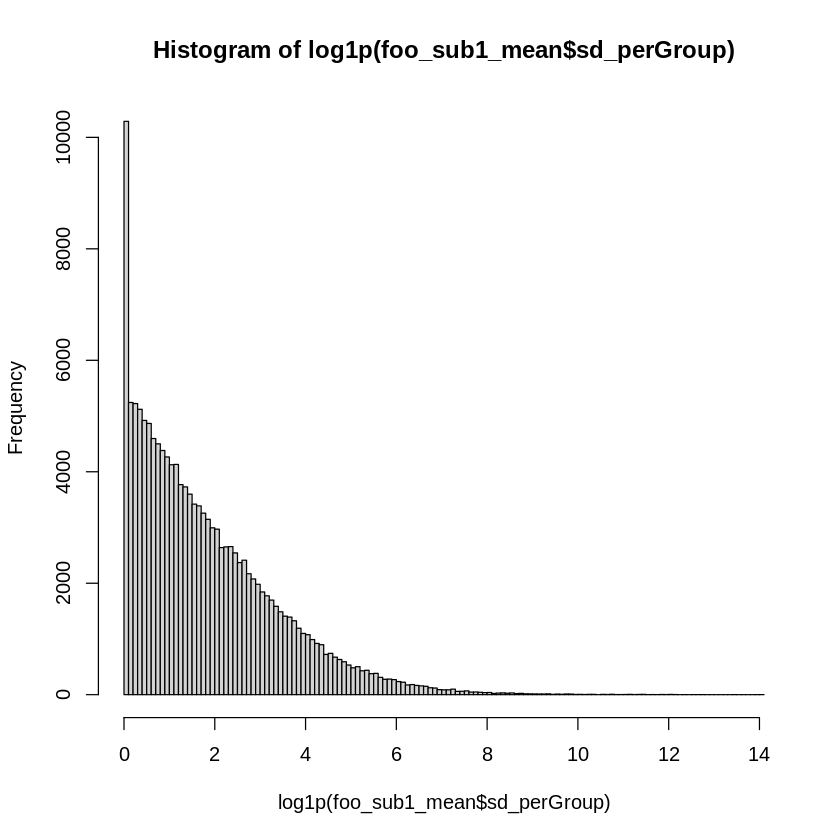

png 
  2

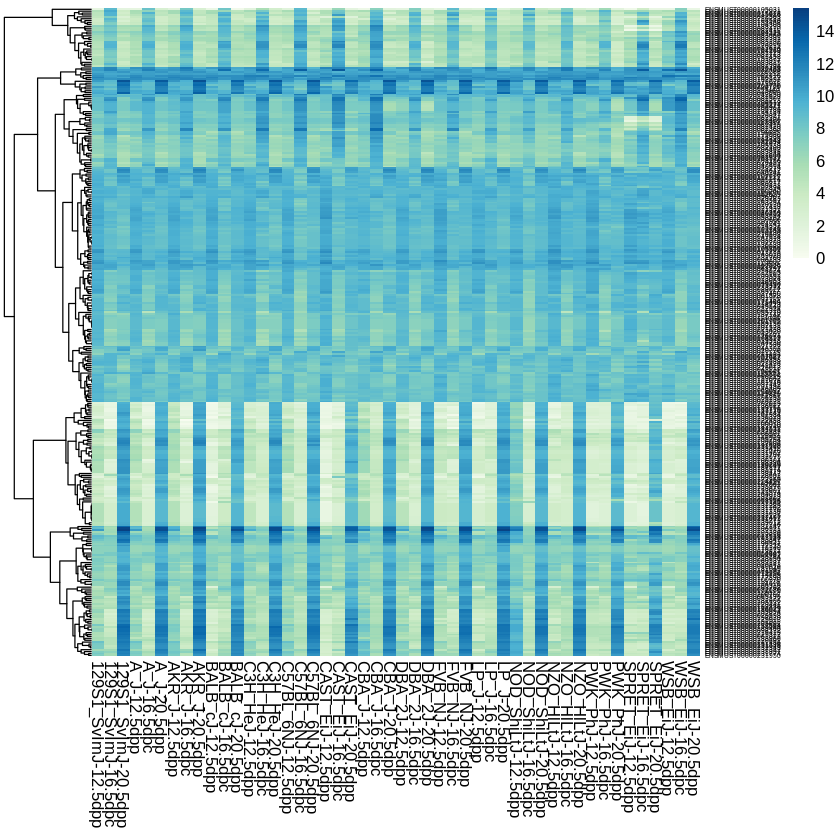

In [29]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:48]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]),width=30000,height=50000, border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(savePheatmap,"InitialPheatMap.pdf")


png 
  2

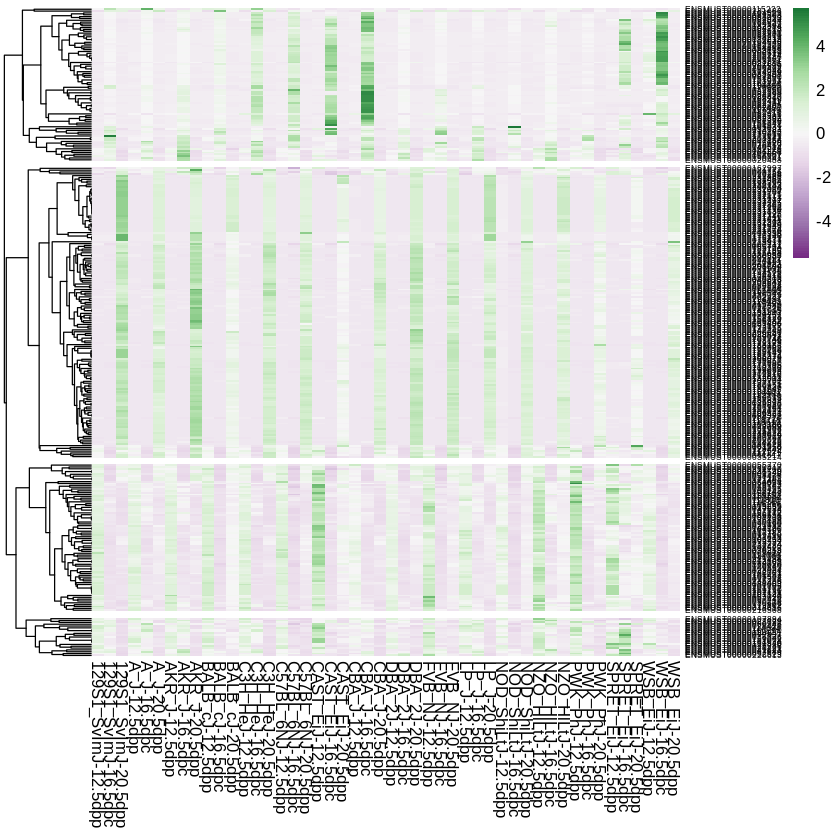

In [30]:
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:48], border_color = NA,show_rownames = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 4,fontsize_row = 5, cluster_cols = F, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"InitialPheatMap_zScore.pdf")

png 
  2

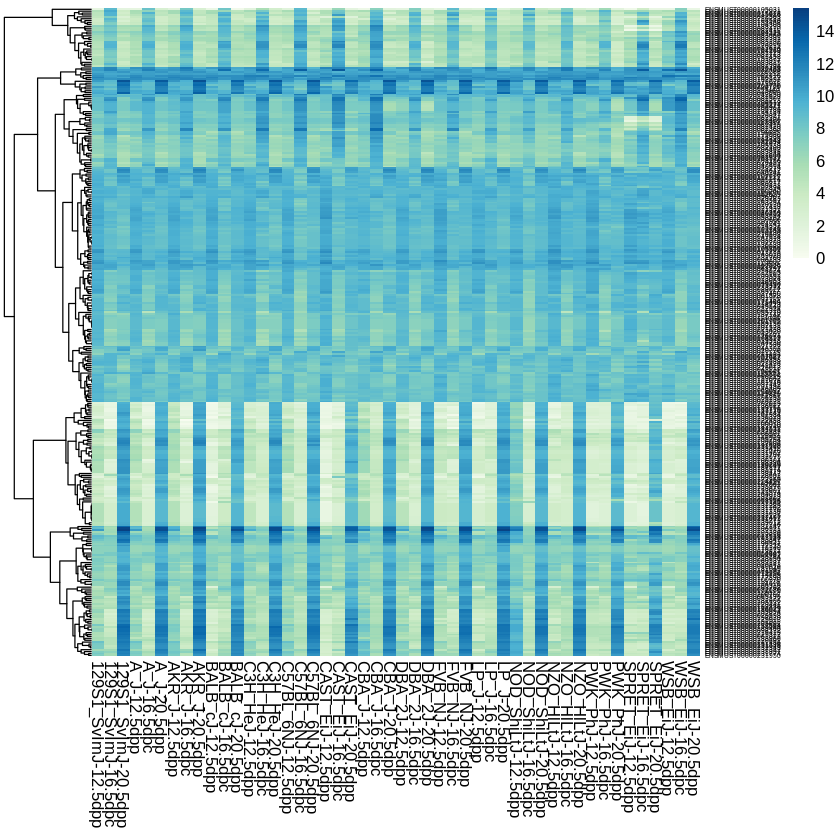

In [31]:
##For log with predeterminde column orderr use cluster_cols = F

logPheatMap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]), border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(logPheatMap,"InitialPheatMap_log.pdf")